In [63]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os, json

# Import Data and Trim

In [72]:
# Specify the path to the JSON file
json_file_path = 'data/raw_data/3600_informed_uniform_a_star_pbs_40.json'  # Adjust the path as needed

# Read the JSON data
with open(json_file_path, 'r') as f:
    data = json.load(f)

data_trim = 200

actual_duration_start_to_pick = data['actual_duration_of_task_from_start_to_pick']
actual_duration_pick_to_place = data['actual_duration_of_task_from_pick_to_place']
estimated_duration_start_to_pick = data['estimated_duration_of_task_from_start_to_pick']
estimated_duration_pick_to_place = data['estimated_duration_of_task_from_pick_to_place']


stationary_robots = data['stationary_robots'][data_trim:]

paths = data['paths']

allocation = data['allocation']


# Stationary Robots Graph

In [62]:
plt.plot(np.arange(data_trim, len(stationary_robots) + data_trim), stationary_robots, '-')

plt.xlabel("Time Step")
plt.ylabel("Number of Stationary Robots")
plt.title("Number of Stationary Robots Over Time")

plt.xticks(np.arange(data_trim, (len(stationary_robots) + data_trim), 400))

# plt.show()
plt.savefig("data/figures/manual_figures/stationary_over_time.png", bbox_inches='tight', dpi=300)

# plt.savefig(os.path.join(folder_path, "number_of_stationary_robots_over_time"), bbox_inches='tight', dpi=300)
plt.clf()

<Figure size 640x480 with 0 Axes>

In [64]:
print("Average Number of Stationary Robots at any given time: ", np.average(stationary_robots))

Average Number of Stationary Robots at any given time:  3.9003234342840343


# Duration Graphs

## Duration Start to Place

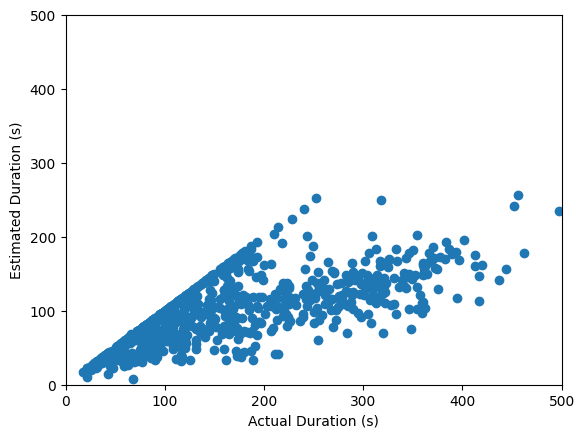

In [73]:
total_actual_duration = (np.asarray(actual_duration_pick_to_place) + np.asarray(actual_duration_start_to_pick)).reshape(-1, 1)
total_estimated_duration = np.asarray(estimated_duration_pick_to_place) + np.asarray(estimated_duration_start_to_pick)

plt.scatter(total_actual_duration, total_estimated_duration)
plt.xlabel("Actual Duration (s)")
plt.ylabel("Estimated Duration (s)")
plt.xlim((0, 500))
plt.ylim((0, 500))

plt.show()

In [75]:
total_actual_duration = np.asarray(actual_duration_pick_to_place) + np.asarray(actual_duration_start_to_pick)
total_estimated_duration = np.asarray(estimated_duration_pick_to_place) + np.asarray(estimated_duration_start_to_pick)

print(len(data['completed_tasks']))

print("Total Number of Tasks: ", len(total_estimated_duration))


print(total_actual_duration == total_estimated_duration)
print(np.count_nonzero(total_actual_duration == total_estimated_duration))

749
Total Number of Tasks:  749
[[False False False ... False False False]
 [False  True False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ...  True False False]
 [False False False ... False False False]
 [False False False ... False False  True]]
2510


## Actual vs. Estimated Duration Pick to Place

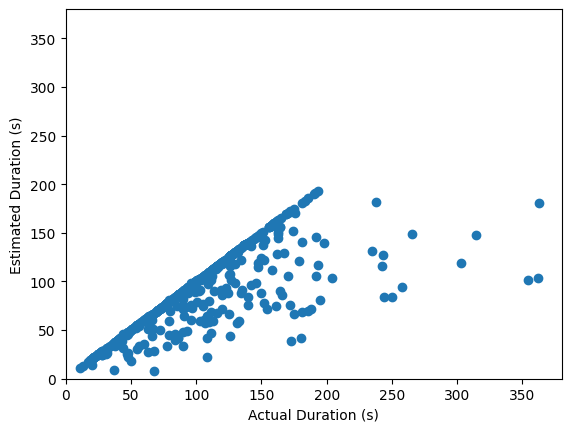

In [36]:
plt.scatter(np.asarray(actual_duration_pick_to_place).reshape(-1, 1), np.asarray(estimated_duration_pick_to_place))
plt.xlabel("Actual Duration (s)")
plt.ylabel("Estimated Duration (s)")
plt.xlim((0, 380))
plt.ylim((0, 380))

plt.show()

## Actual vs. Estimated Duration Start to Pick

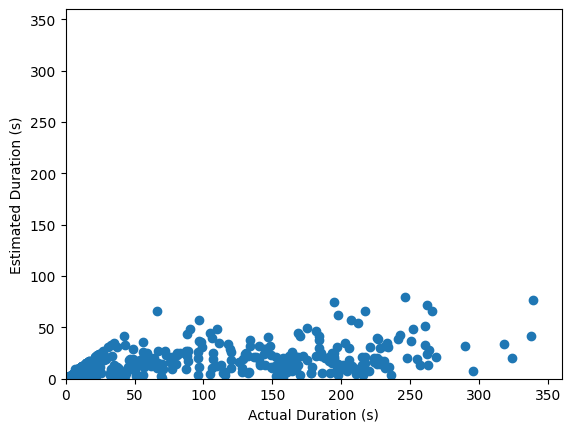

In [48]:
plt.scatter(np.asarray(actual_duration_start_to_pick).reshape(-1, 1), np.asarray(estimated_duration_start_to_pick))
plt.xlabel("Actual Duration (s)")
plt.ylabel("Estimated Duration (s)")
plt.xlim((0, 360))
plt.ylim((0, 360))

plt.show()

## Robots Getting Stuck 

(40, 3601, 2)
[[ 66  60]
 [ 56  14]
 [118  21]
 [114  42]
 [ 82  18]
 [ 22  42]
 [104  76]
 [117  48]
 [ 85   0]
 [ 33  14]
 [114   9]
 [  9  44]
 [116  57]
 [ 61  16]
 [116  63]
 [ 71  76]
 [108  28]
 [117  42]
 [ 22  14]
 [108  60]
 [ 80   8]
 [ 59   8]
 [102   2]
 [ 53   8]
 [ 89  84]
 [ 33  16]
 [ 19  36]
 [115   0]
 [116  30]
 [ 67  56]
 [ 64  88]
 [ 95  66]
 [ 35  62]
 [118  54]
 [111  35]
 [ 32  36]
 [ 20  72]
 [ 73  28]
 [114  15]
 [115  84]]


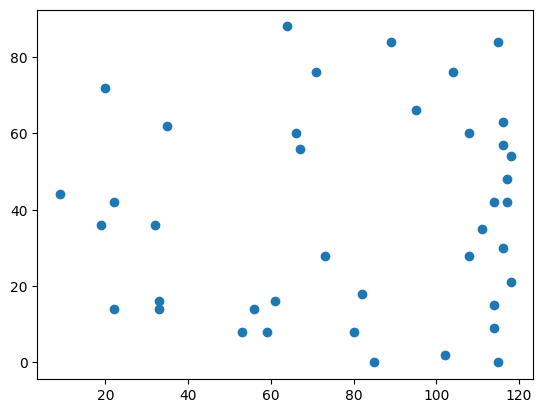

In [56]:
paths = np.asarray(paths)

print(paths.shape)

last_position = paths[:, -1, :]

print(last_position)

plt.scatter(last_position[:, 0], last_position[:, 1])
plt.show()

In [59]:
print(allocation)

[[[0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9], [0, 9]